# Basic_박상우_6주차

3.1 ~ 3.5 정리

## 3.1 Accuracy

In [6]:
import sklearn

print(sklearn.__version__)

1.8.0


In [7]:
import numpy as np
from sklearn.base import BaseEstimator

class MyDummyClassifier(BaseEstimator):
    def fit(self, X, y=None):
        # 학습 자체는 하지 않고 규칙만 그대로 쓴다.
        return self

    def predict(self, X):
        # Sex가 1이면 남성으로 보고 사망(0), 아니면 생존(1)으로 단순 예측
        pred = np.zeros(X.shape[0], dtype=int)
        for i in range(X.shape[0]):
            pred[i] = 0 if X['Sex'].iloc[i] == 1 else 1
        return pred

In [8]:
from sklearn.preprocessing import LabelEncoder

def fillna(df):
    # 결측치는 평균값이나 기본값으로 먼저 채운다.
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

def drop_features(df):
    # 예측에 바로 쓰기 애매한 컬럼은 제거
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

def format_features(df):
    # Cabin은 맨 앞 알파벳만 남기고 범주형 컬럼은 숫자로 바꾼다.
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        df[feature] = le.fit_transform(df[feature])
    return df

def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 타이타닉 데이터에서 정답 컬럼만 따로 분리
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

# 전처리 후 학습용/테스트용 데이터로 나눈다.
X_titanic_df = transform_features(X_titanic_df)
X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_df, y_titanic_df, test_size=0.2, random_state=0
)

myclf = MyDummyClassifier()
myclf.fit(X_train, y_train)
mypredictions = myclf.predict(X_test)

print('Dummy Classifier 정확도: {0:.4f}'.format(accuracy_score(y_test, mypredictions)))

Dummy Classifier 정확도: 0.7877


C:\Users\mac04\AppData\Local\Temp\ipykernel_38492\3594288981.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\mac04\AppData\Local\Temp\ipykernel_38492\3594288981.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

## 3.2 Confusion Matrix

In [10]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

class MyFakeClassifier(BaseEstimator):
    def fit(self, X, y):
        return self

    def predict(self, X):
        # 전부 0으로만 예측하면 정확도가 어떻게 나오는지 보려고 만든 클래스
        return np.zeros(len(X), dtype=bool)

digits = load_digits()

# 숫자 7만 1로 보고 나머지는 전부 0으로 바꾼다.
y = (digits.target == 7).astype(int)
X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=11)

print('테스트 세트 크기:', y_test.shape)
print(pd.Series(y_test).value_counts())

fakeclf = MyFakeClassifier()
fakeclf.fit(X_train, y_train)
fakepred = fakeclf.predict(X_test)

print('전부 0으로 예측한 정확도: {:.3f}'.format(accuracy_score(y_test, fakepred)))
print(confusion_matrix(y_test, fakepred))

테스트 세트 크기: (450,)
0    405
1     45
Name: count, dtype: int64
전부 0으로 예측한 정확도: 0.900
[[405   0]
 [ 45   0]]


## 3.3 Precision / Recall

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

def get_clf_eval(y_test, pred):
    # 오차행렬과 기본 분류 지표를 한 번에 확인하려고 함수로 묶었다.
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}'.format(accuracy, precision, recall))

titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)
X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_df, y_titanic_df, test_size=0.20, random_state=11
)

# 로지스틱 회귀로 기본 분류 성능을 확인
lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)

get_clf_eval(y_test, pred)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


C:\Users\mac04\AppData\Local\Temp\ipykernel_38492\3594288981.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\mac04\AppData\Local\Temp\ipykernel_38492\3594288981.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [12]:
from sklearn.preprocessing import Binarizer

pred_proba = lr_clf.predict_proba(X_test)
print('pred_proba shape:', pred_proba.shape)
print(pred_proba[:3])

# 1에 대한 확률만 뽑아서 임계값 기준으로 0, 1을 다시 나눈다.
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]

for custom_threshold in thresholds:
    binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
    custom_predict = binarizer.transform(pred_proba_1)
    print('\n임계값:', custom_threshold)
    get_clf_eval(y_test, custom_predict)

pred_proba shape: (179, 2)
[[0.44935228 0.55064772]
 [0.86335513 0.13664487]
 [0.86429646 0.13570354]]

임계값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197

임계값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869

임계값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705

임계값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377

임계값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213


thresholds sample: [0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
precisions sample: [0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
recalls sample: [1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


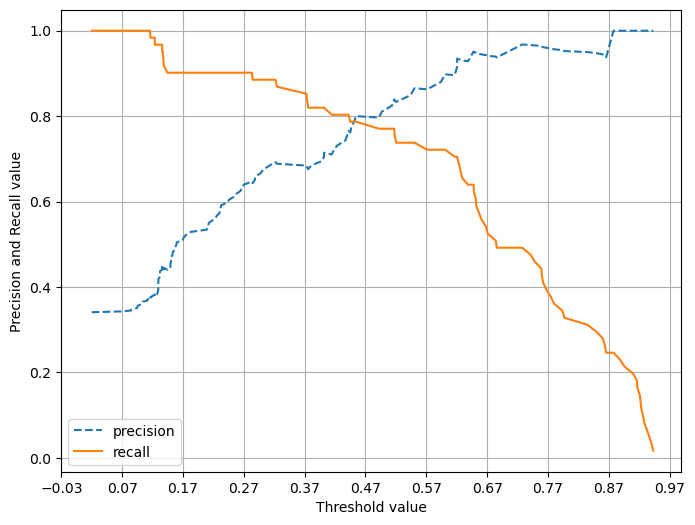

In [13]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

def precision_recall_curve_plot(y_test, pred_proba_c1):
    # 임계값이 바뀔 때 정밀도, 재현율이 같이 어떻게 움직이는지 본다.
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precisions[:-1], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[:-1], label='recall')
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlabel('Threshold value')
    plt.ylabel('Precision and Recall value')
    plt.legend()
    plt.grid()
    plt.show()

pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1)
thr_index = np.arange(0, thresholds.shape[0], 15)

print('thresholds sample:', np.round(thresholds[thr_index], 2))
print('precisions sample:', np.round(precisions[thr_index], 3))
print('recalls sample:', np.round(recalls[thr_index], 3))

precision_recall_curve_plot(y_test, pred_proba_class1)

## 3.4 F1 Score

In [14]:
from sklearn.metrics import f1_score
from sklearn.preprocessing import Binarizer

def get_clf_eval_with_f1(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}'.format(accuracy, precision, recall, f1))

# F1 점수는 정밀도와 재현율을 같이 보고 싶을 때 많이 쓴다.
print('기본 F1 Score: {0:.4f}'.format(f1_score(y_test, pred)))

thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]
pred_proba = lr_clf.predict_proba(X_test)[:, 1].reshape(-1, 1)

for custom_threshold in thresholds:
    binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba)
    custom_predict = binarizer.transform(pred_proba)
    print('\n임계값:', custom_threshold)
    get_clf_eval_with_f1(y_test, custom_predict)

기본 F1 Score: 0.7966

임계값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197, F1: 0.7576

임계값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869, F1: 0.7869

임계값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705, F1: 0.7966

임계값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377, F1: 0.7965

임계값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213, F1: 0.8000


## 3.5 ROC Curve / AUC

thresholds sample: [0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
FPR sample: [0.    0.008 0.025 0.076 0.127 0.254 0.576 0.61  0.746 0.847]
TPR sample: [0.016 0.492 0.705 0.738 0.803 0.885 0.902 0.951 0.967 1.   ]


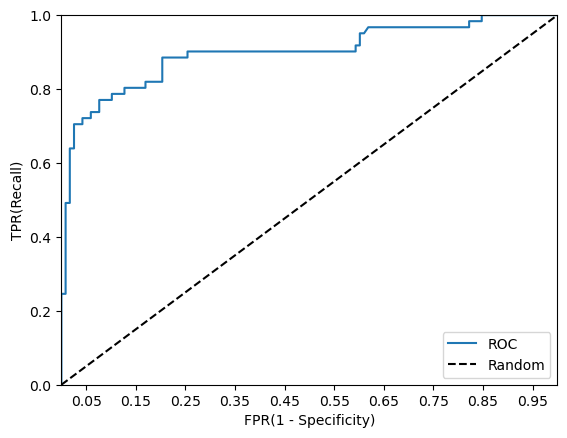

ROC AUC 값: 0.8987
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705, F1: 0.7966, AUC: 0.8987


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

def roc_curve_plot(y_test, pred_proba_c1):
    # ROC 곡선은 FPR, TPR 변화로 분류 성능을 본다.
    fprs, tprs, thresholds = roc_curve(y_test, pred_proba_c1)
    plt.plot(fprs, tprs, label='ROC')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('FPR(1 - Specificity)')
    plt.ylabel('TPR(Recall)')
    plt.legend()
    plt.show()

pred_proba = lr_clf.predict_proba(X_test)[:, 1]
fprs, tprs, thresholds = roc_curve(y_test, pred_proba)
thr_index = np.arange(1, thresholds.shape[0], 5)

print('thresholds sample:', np.round(thresholds[thr_index], 2))
print('FPR sample:', np.round(fprs[thr_index], 3))
print('TPR sample:', np.round(tprs[thr_index], 3))

roc_curve_plot(y_test, pred_proba)
print('ROC AUC 값: {0:.4f}'.format(roc_auc_score(y_test, pred_proba)))

def get_clf_eval_with_auc(y_test, pred, pred_proba):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

pred = lr_clf.predict(X_test)
get_clf_eval_with_auc(y_test, pred, pred_proba)